# Mejoras del Modelo Temporal — Optimización y Comparativa

## Caso Práctico - Empresa de Telecomunicaciones
## Prácticas Aplicadas 2026

---

## Contexto y motivación

En el notebook anterior obtuvimos un AUC de **0.685** con la Regresión Logística Temporal. El objetivo de este notebook es mejorar ese resultado mediante tres palancas:

1. **Tratar el desbalance extremo**: hay 160 clientes que no churnearon por cada uno que sí lo hizo. Los modelos estándar tienden a ignorar la clase minoritaria en estos casos.

2. **Optimizar hiperparámetros con GridSearchCV**: en lugar de usar valores por defecto, buscamos sistemáticamente la combinación que maximiza el AUC.

3. **Probar XGBoost**: un algoritmo de boosting que suele funcionar muy bien en problemas con desbalance y variables mixtas.

Al final comparamos todos los modelos con métricas completas: AUC, Accuracy, Precision, Recall y F1.


## ¿Por qué el desbalance es un problema?

La tasa de churn mensual es del **0.62%**, lo que implica un ratio de **160:1** entre no churners y churners. En este contexto:

- Un modelo que prediga **siempre 'No Churn'** tendría un accuracy del 99.38% — pero sería completamente inútil.
- El AUC-ROC es más robusto al desbalance, pero los modelos siguen teniendo dificultad para aprender de tan pocos positivos.

Las soluciones que aplicamos:
- **`class_weight='balanced'`**: penaliza más los errores en la clase minoritaria, forzando al modelo a prestarle más atención.
- **`scale_pos_weight` en XGBoost**: equivalente al anterior para el algoritmo de boosting.


## 1. Librerías


In [2]:
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix,
    ConfusionMatrixDisplay, average_precision_score
)

try:
    from xgboost import XGBClassifier
    print('XGBoost disponible')
except ImportError:
    print('XGBoost no instalado. Ejecuta: pip install xgboost')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.load import load_all
from src.clean import clean_all

RANDOM_STATE = 42
print('Librerías cargadas')

XGBoost disponible
Librerías cargadas


## 2. Carga y construcción del panel

Reutilizamos exactamente la misma construcción del panel temporal del notebook anterior. La diferencia estará en el preprocesado y los modelos.


In [3]:
data  = load_all()
clean = clean_all(data, save=False)

clientes  = clean['clientes']
churn     = clean['churn']
factura   = clean['facturacion']
soporte   = clean['soporte']
calidad   = clean['calidad']

print('\nDatos cargados')

  CARGANDO DATASETS
[load] clientes:    10,150 filas x 14 columnas
[load] churn:       321,987 filas x 3 columnas
[load] facturacion: 326,816 filas x 14 columnas
[load] soporte:     308,487 filas x 13 columnas
[load] calidad:     1,096 filas x 12 columnas
[load] encuestas:   1,015 filas x 13 columnas

✅ Todos los datasets cargados correctamente

  LIMPIANDO DATASETS

[clean_clientes] Eliminados 150 duplicados exactos
[clean_clientes] 145 antigüedades negativas → 0
[clean_clientes] 10,150 → 10,000 filas | Nulos restantes: 1022
[clean_churn] 321,987 → 321,987 filas
[clean_facturacion] Eliminados 4829 duplicados exactos
[clean_facturacion] 9659 registros con importe_total nulo (se mantienen como NaN — posibles errores de sistema)
[clean_facturacion] 3636 registros con consumo_extra negativo (abonos/correcciones — se mantienen)
[clean_facturacion] 326,816 → 321,987 filas
[clean_soporte] Eliminados 4558 duplicados exactos
[clean_soporte] 4558 duraciones fuera de rango → NaN
[clean_soporte] 

In [4]:
# ── Construcción del panel (misma lógica que modelo temporal) ─────────────

# Facturación mensual
factura['mes'] = factura['fecha'].dt.to_period('M').dt.to_timestamp()
factura_mes = factura.groupby(['cliente_id', 'mes']).agg(
    importe_mes       = ('importe_total',        'sum'),
    impago_mes        = ('impago_flag',           'max'),
    dias_retraso_mes  = ('dias_retraso_pago',     'max'),
    stress_mes        = ('stress_calidad_lag',    'mean'),
    consumo_extra_mes = ('consumo_extra',         'sum'),
    variacion_consumo = ('variacion_consumo_pct', 'mean'),
    descuento_mes     = ('descuento_aplicado',    'sum'),
).reset_index()

# Soporte mensual
soporte['mes_soporte'] = soporte['mes'].dt.to_period('M').dt.to_timestamp()
soporte_mes = soporte.groupby(['cliente_id', 'mes_soporte']).agg(
    n_interacciones_mes = ('interaccion_id',    'count'),
    resolucion_mes      = ('resuelto',          'mean'),
    satisfaccion_mes    = ('satisfaccion_post', 'mean'),
    n_baja_mes          = ('motivo', lambda x: (x == 'Baja / portabilidad').sum()),
).reset_index().rename(columns={'mes_soporte': 'mes'})

# Panel base
panel = churn.copy()
panel['mes'] = panel['fecha'].dt.to_period('M').dt.to_timestamp()

# Lag 1 — facturación
factura_lag = factura_mes.copy()
factura_lag['mes'] = factura_lag['mes'] + pd.DateOffset(months=1)
factura_lag = factura_lag.rename(columns={
    c: f'{c}_lag1' for c in factura_lag.columns if c not in ['cliente_id', 'mes']
})
panel = panel.merge(factura_lag, on=['cliente_id', 'mes'], how='left')

# Rolling 3 meses — facturación
factura_sorted = factura_mes.sort_values(['cliente_id', 'mes'])
for col in ['impago_mes', 'stress_mes', 'variacion_consumo', 'dias_retraso_mes']:
    factura_sorted[f'{col}_roll3'] = (
        factura_sorted.groupby('cliente_id')[col]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )
roll_cols = ['cliente_id', 'mes',
             'impago_mes_roll3', 'stress_mes_roll3',
             'variacion_consumo_roll3', 'dias_retraso_mes_roll3']
factura_roll = factura_sorted[roll_cols].copy()
factura_roll['mes'] = factura_roll['mes'] + pd.DateOffset(months=1)
panel = panel.merge(factura_roll, on=['cliente_id', 'mes'], how='left')

# Lag 1 — soporte
soporte_lag = soporte_mes.copy()
soporte_lag['mes'] = soporte_lag['mes'] + pd.DateOffset(months=1)
soporte_lag = soporte_lag.rename(columns={
    c: f'{c}_lag1' for c in soporte_lag.columns if c not in ['cliente_id', 'mes']
})
panel = panel.merge(soporte_lag, on=['cliente_id', 'mes'], how='left')
for col in ['n_interacciones_mes_lag1', 'n_baja_mes_lag1']:
    panel[col] = panel[col].fillna(0)

# Calidad de red lag 1
calidad['mes'] = calidad['fecha'].dt.to_period('M').dt.to_timestamp()
calidad_lag = calidad[['zona_id', 'mes', 'indice_calidad_global',
                         'tasa_cortes_pct', 'cobertura_5g_pct']].copy()
calidad_lag['mes'] = calidad_lag['mes'] + pd.DateOffset(months=1)
calidad_lag = calidad_lag.rename(columns={
    'indice_calidad_global': 'calidad_global_lag1',
    'tasa_cortes_pct':       'tasa_cortes_lag1',
    'cobertura_5g_pct':      'cobertura_5g_lag1',
})
zona_cliente = clientes[['cliente_id', 'zona_id']]
panel = panel.merge(zona_cliente, on='cliente_id', how='left')
panel = panel.merge(calidad_lag, on=['zona_id', 'mes'], how='left')

# Perfil estático + mapeo ordinal
cols_perfil = ['cliente_id', 'edad', 'sexo', 'estado_civil', 'num_lineas',
               'tipo_plan', 'tipo_zona', 'region', 'ingreso_estimado',
               'antiguedad_meses', 'descuento_activo', 'tipo_dispositivo']
cols_perfil_disp = [c for c in cols_perfil if c in clientes.columns]
panel = panel.merge(clientes[cols_perfil_disp], on='cliente_id', how='left')
panel['tipo_plan_num'] = panel['tipo_plan'].map({'Básico': 1, 'Estándar': 2, 'Premium': 3})

print(f'Panel: {panel.shape[0]:,} filas x {panel.shape[1]} columnas')
print(f'Tasa de churn: {panel["churn"].mean()*100:.2f}%')
print(f'Ratio desbalance: {round((panel["churn"]==0).sum()/panel["churn"].sum(),0):.0f}:1')

Panel: 321,987 filas x 35 columnas
Tasa de churn: 0.62%
Ratio desbalance: 160:1


## 3. Selección de variables mejorada

Respecto al notebook anterior, hacemos dos cambios:
1. **Eliminamos `resolucion_mes_lag1` y `satisfaccion_mes_lag1`** — tienen más del 90% de nulos porque el soporte solo cubre el 8.6% de los cliente-mes. El imputer no puede compensar tanta ausencia de datos.
2. **Añadimos `dias_retraso_mes_roll3`** — la tendencia de retrasos en los últimos 3 meses, que vimos como variable importante en el Random Forest.


In [5]:
FEATURES_NUM = [
    # Perfil
    'edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'descuento_activo',
    # Facturación lag 1
    'importe_mes_lag1', 'impago_mes_lag1', 'dias_retraso_mes_lag1',
    'stress_mes_lag1', 'consumo_extra_mes_lag1', 'variacion_consumo_lag1',
    # Rolling 3 meses (tendencia)
    'impago_mes_roll3', 'stress_mes_roll3',
    'variacion_consumo_roll3', 'dias_retraso_mes_roll3',
    # Soporte lag 1 (solo las que no tienen exceso de nulos)
    'n_interacciones_mes_lag1', 'n_baja_mes_lag1',
    # Calidad de red lag 1
    'calidad_global_lag1', 'tasa_cortes_lag1', 'cobertura_5g_lag1',
]

FEATURES_CAT_NOMINAL = [
    'region', 'tipo_zona', 'sexo', 'estado_civil', 'tipo_dispositivo',
]

FEATURES_ORDINAL = ['tipo_plan_num']

TARGET = 'churn'
all_features = FEATURES_NUM + FEATURES_CAT_NOMINAL + FEATURES_ORDINAL

missing = [f for f in all_features if f not in panel.columns]
if missing:
    print(f'⚠️ No encontradas: {missing}')
else:
    print(f'✅ {len(all_features)} variables disponibles')

✅ 26 variables disponibles


## 4. División train / test


In [6]:
clientes_unicos = panel['cliente_id'].unique()
np.random.seed(RANDOM_STATE)
clientes_test  = np.random.choice(clientes_unicos,
                                   size=int(len(clientes_unicos) * 0.2),
                                   replace=False)
clientes_train = np.setdiff1d(clientes_unicos, clientes_test)

train = panel[panel['cliente_id'].isin(clientes_train)].dropna(
    subset=['importe_mes_lag1', 'stress_mes_lag1']).copy()
test  = panel[panel['cliente_id'].isin(clientes_test)].dropna(
    subset=['importe_mes_lag1', 'stress_mes_lag1']).copy()

X_train = train[all_features]
y_train = train[TARGET]
X_test  = test[all_features]
y_test  = test[TARGET]

# Ratio de desbalance para XGBoost
RATIO_DESBALANCE = round((y_train == 0).sum() / y_train.sum())

print(f'Train: {len(X_train):,} filas | {y_train.mean()*100:.2f}% churn')
print(f'Test:  {len(X_test):,} filas  | {y_test.mean()*100:.2f}% churn')
print(f'Ratio desbalance: {RATIO_DESBALANCE}:1')

Train: 249,463 filas | 0.64% churn
Test:  62,524 filas  | 0.63% churn
Ratio desbalance: 156:1


## 5. Preprocesador


In [7]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
nom_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='desconocido')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])
ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, FEATURES_NUM),
    ('nom', nom_pipeline, FEATURES_CAT_NOMINAL),
    ('ord', ord_pipeline, FEATURES_ORDINAL),
])

# Validación cruzada estratificada para GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Preprocesador definido')

Preprocesador definido


## 6. Función de evaluación

Definimos una función que calcula todas las métricas de una vez para poder comparar modelos de forma limpia.


In [8]:
def evaluar_modelo(nombre, y_true, y_pred_proba, umbral=0.05):
    """
    Calcula AUC-ROC, AUC-PR, Accuracy, Precision, Recall y F1
    para un modelo dado su probabilidad predicha.
    El umbral por defecto es 0.05 en lugar de 0.5
    porque con 0.63% de churn el 0.5 apenas detecta positivos.
    """
    y_pred = (y_pred_proba >= umbral).astype(int)

    return {
        'Modelo':     nombre,
        'AUC-ROC':    round(roc_auc_score(y_true, y_pred_proba), 3),
        'AUC-PR':     round(average_precision_score(y_true, y_pred_proba), 3),
        'Accuracy':   round(accuracy_score(y_true, y_pred), 3),
        'Precision':  round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall':     round(recall_score(y_true, y_pred, zero_division=0), 3),
        'F1':         round(f1_score(y_true, y_pred, zero_division=0), 3),
    }

resultados = []  # acumulamos aquí todos los modelos
probas = {}      # guardamos las probabilidades para las curvas

print('Función de evaluación definida')
print('Métricas que calcularemos: AUC-ROC, AUC-PR, Accuracy, Precision, Recall, F1')
print(f'Umbral de decisión: 0.05 (adaptado al desbalance 160:1)')

Función de evaluación definida
Métricas que calcularemos: AUC-ROC, AUC-PR, Accuracy, Precision, Recall, F1
Umbral de decisión: 0.05 (adaptado al desbalance 160:1)


---
## 7. Modelo 1 — Regresión Logística con `class_weight='balanced'`

El parámetro `class_weight='balanced'` hace que el modelo penalice 160 veces más los errores sobre churners que sobre no churners. Es la forma más sencilla de compensar el desbalance sin modificar los datos.


In [9]:
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

pipe_lr.fit(X_train, y_train)
proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
probas['LR Balanced'] = proba_lr

res_lr = evaluar_modelo('LR Balanced', y_test, proba_lr)
resultados.append(res_lr)

print('\nRegresión Logística (balanced):')
for k, v in res_lr.items():
    print(f'  {k}: {v}')


Regresión Logística (balanced):
  Modelo: LR Balanced
  AUC-ROC: 0.688
  AUC-PR: 0.016
  Accuracy: 0.007
  Precision: 0.006
  Recall: 1.0
  F1: 0.013


---
## 8. GridSearch — Los tres modelos con estructura unificada

En lugar de hacer un GridSearch separado por modelo, usamos un **diccionario de configuraciones** que itera sobre todos de una vez. Esto hace el código más limpio y fácil de extender con nuevos modelos.

Los modelos que comparamos:
1. **Regresión Logística** — interpretable, buena base de referencia
2. **Random Forest** — reduce varianza mediante bagging
3. **XGBoost** — boosting secuencial, suele ser el más competitivo

Para todos usamos `scoring='roc_auc'` porque con desbalance 160:1 el AUC es más robusto que el F1 (no depende del umbral de decisión).

Para compensar el desbalance:
- `class_weight='balanced'` en LR y RF
- `scale_pos_weight=RATIO_DESBALANCE` en XGBoost

Usamos `cv=5` (5 folds) en lugar de 3 para obtener una estimación más estable del AUC.


In [10]:
from xgboost import XGBClassifier

# Preprocesamos los datos una sola vez para XGBoost
# (XGBoost no acepta Pipeline con ColumnTransformer directamente en GridSearch)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# ── Diccionario de configuraciones ───────────────────────────────────────
# Estructura inspirada en el trabajo de ML anterior:
# cada modelo tiene su pipeline/estimador y su grid de parámetros
model_configs = {
    'Regresión Logística': {
        'estimator': Pipeline([
            ('preprocessor', preprocessor),
            ('model', LogisticRegression(
                class_weight='balanced',
                random_state=RANDOM_STATE,
                max_iter=1000,
                solver='saga'
            ))
        ]),
        'params': {
            'model__C':       [0.01, 0.1, 1.0, 10.0],
            'model__penalty': ['l1', 'l2'],
        },
        'usa_prep': False,  # usa el pipeline con preprocessor interno
    },
    'Random Forest': {
        'estimator': Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestClassifier(
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        'params': {
            'model__n_estimators':     [100, 200],
            'model__max_depth':        [5, 8, 12],
            'model__min_samples_leaf': [10, 20, 50],
        },
        'usa_prep': False,
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            scale_pos_weight=RATIO_DESBALANCE,
            random_state=RANDOM_STATE,
            eval_metric='auc',
            verbosity=0
        ),
        'params': {
            'n_estimators':  [200, 400],
            'max_depth':     [4, 6, 8],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample':     [0.7, 0.9],
        },
        'usa_prep': True,  # usa X_train_prep (ya preprocesado)
    },
}

# ── Bucle de GridSearch ───────────────────────────────────────────────────
best_estimators = {}

for nombre, config in model_configs.items():
    print(f'\n--- GridSearch: {nombre} ---')

    X_tr = X_train_prep if config['usa_prep'] else X_train
    X_te = X_test_prep  if config['usa_prep'] else X_test

    gs = GridSearchCV(
        config['estimator'],
        config['params'],
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    gs.fit(X_tr, y_train)

    print(f'  Mejores parámetros: {gs.best_params_}')
    print(f'  Mejor AUC en CV:    {gs.best_score_:.3f}')

    proba = gs.predict_proba(X_te)[:, 1]
    probas[nombre] = proba
    best_estimators[nombre] = gs.best_estimator_

    res = evaluar_modelo(nombre, y_test, proba)
    resultados.append(res)

    print(f'  AUC en test: {res["AUC-ROC"]:.3f} | '
          f'Recall: {res["Recall"]:.3f} | '
          f'F1: {res["F1"]:.3f}')

print('\n✅ GridSearch completado para todos los modelos')



--- GridSearch: Regresión Logística ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Mejores parámetros: {'model__C': 0.1, 'model__penalty': 'l1'}
  Mejor AUC en CV:    0.702
  AUC en test: 0.689 | Recall: 1.000 | F1: 0.013

--- GridSearch: Random Forest ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits
  Mejores parámetros: {'model__max_depth': 5, 'model__min_samples_leaf': 20, 'model__n_estimators': 200}
  Mejor AUC en CV:    0.687
  AUC en test: 0.674 | Recall: 1.000 | F1: 0.013

--- GridSearch: XGBoost ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits
  Mejores parámetros: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.7}
  Mejor AUC en CV:    0.689
  AUC en test: 0.679 | Recall: 1.000 | F1: 0.013

✅ GridSearch completado para todos los modelos


---
## 9. Comparativa completa de modelos

Reunimos todos los resultados en una tabla y los visualizamos.

**Nota sobre las métricas con desbalance extremo**:
- **Accuracy** no es útil aquí — un modelo que prediga siempre 'No Churn' tendría 99.38% de accuracy.
- **AUC-ROC** mide la capacidad de separar las clases, independientemente del umbral.
- **AUC-PR** (Precision-Recall) es más informativa con desbalance extremo porque penaliza más los falsos positivos.
- **Recall** mide cuántos churners detectamos — lo más importante para el negocio.
- **Precision** mide cuántos de los que marcamos como churn realmente lo son.
- **F1** es la media armónica entre Precision y Recall.


In [11]:
df_resultados = pd.DataFrame(resultados).set_index('Modelo')

# Añadimos referencia del modelo anterior (sin mejoras)
df_resultados.loc['LR Temporal (anterior)'] = {
    'AUC-ROC': 0.685, 'AUC-PR': None,
    'Accuracy': None, 'Precision': None,
    'Recall': None, 'F1': None
}

print('=== COMPARATIVA COMPLETA DE MODELOS ===')
display(df_resultados.style.highlight_max(
    subset=['AUC-ROC', 'AUC-PR', 'Recall', 'F1'],
    color='#c8f5c8'
).format('{:.3f}', na_rep='-'))

=== COMPARATIVA COMPLETA DE MODELOS ===


,AUC-ROC,AUC-PR,Accuracy,Precision,Recall,F1
Modelo,,,,,,
LR Balanced,0.688,0.016,0.007,0.006,1.000,0.013
Regresión Logística,0.689,0.015,0.007,0.006,1.000,0.013
Random Forest,0.674,0.014,0.006,0.006,1.000,0.013
XGBoost,0.679,0.015,0.006,0.006,1.000,0.013
LR Temporal (anterior),0.685,-,-,-,-,-


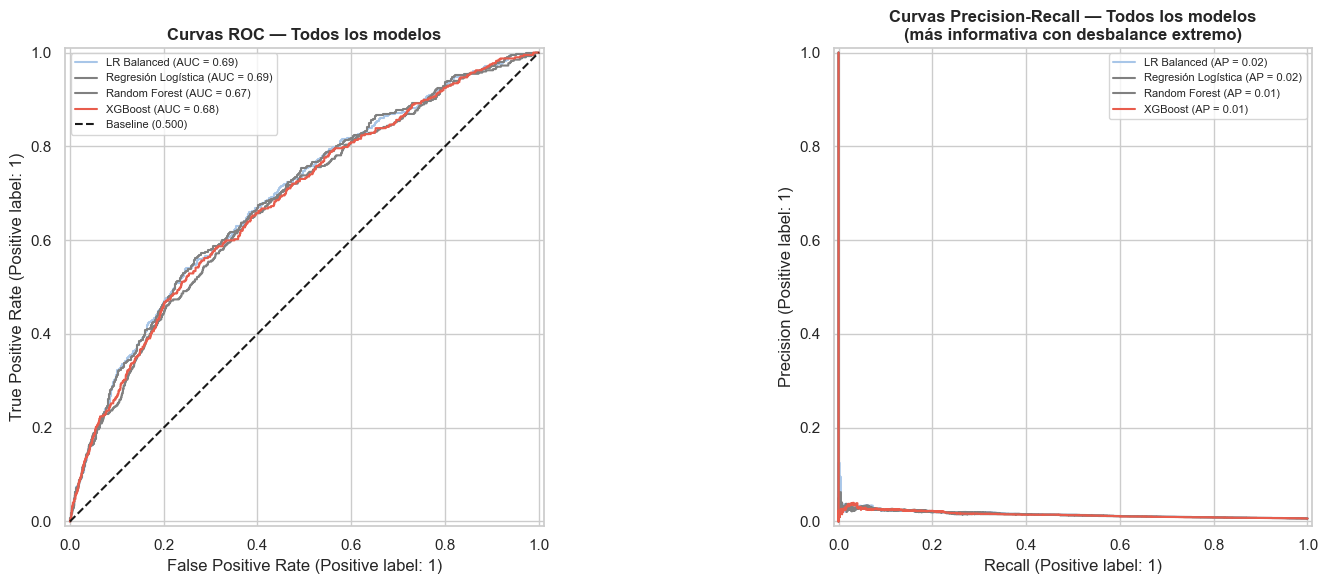

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colores_modelos = {
    'LR Balanced':       '#a8c6e8',
    'LR GridSearch':     '#4C9BE8',
    'RF GridSearch':     '#f5a4a0',
    'XGBoost':           '#E85C4C',
    'XGBoost GridSearch':'#8B0000',
}

# Curvas ROC
for nombre, proba in probas.items():
    RocCurveDisplay.from_predictions(
        y_test, proba,
        name=nombre,
        color=colores_modelos.get(nombre, 'gray'),
        ax=axes[0]
    )
axes[0].plot([0,1],[0,1],'k--', label='Baseline (0.500)')
axes[0].set_title('Curvas ROC — Todos los modelos', fontweight='bold')
axes[0].legend(fontsize=8)

# Curvas Precision-Recall
for nombre, proba in probas.items():
    PrecisionRecallDisplay.from_predictions(
        y_test, proba,
        name=nombre,
        color=colores_modelos.get(nombre, 'gray'),
        ax=axes[1]
    )
axes[1].set_title('Curvas Precision-Recall — Todos los modelos\n'
                   '(más informativa con desbalance extremo)',
                   fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

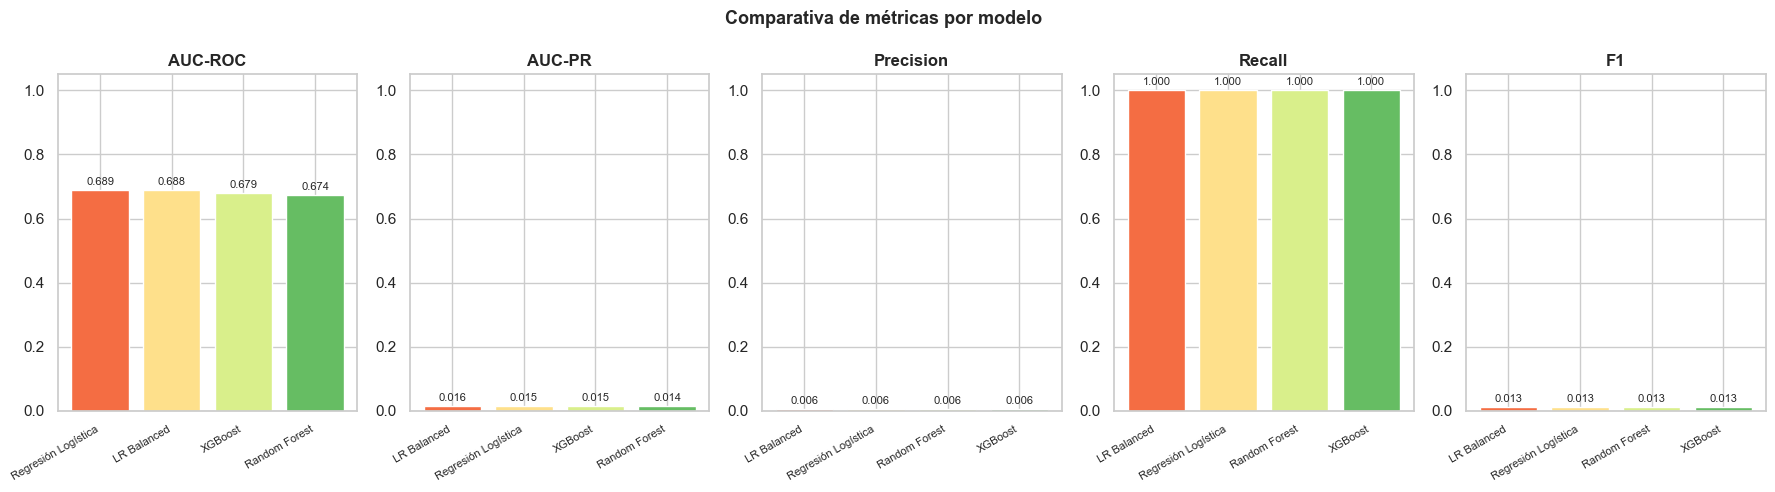

In [13]:
# Gráfico de barras comparativo por métrica
metricas_plot = ['AUC-ROC', 'AUC-PR', 'Precision', 'Recall', 'F1']
df_plot = df_resultados.drop('LR Temporal (anterior)', errors='ignore')[metricas_plot]

fig, axes = plt.subplots(1, len(metricas_plot), figsize=(18, 5))

for i, metrica in enumerate(metricas_plot):
    vals = df_plot[metrica].sort_values(ascending=False)
    bars = axes[i].bar(range(len(vals)), vals.values,
                       color=sns.color_palette('RdYlGn', len(vals)))
    axes[i].set_title(metrica, fontweight='bold')
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    axes[i].set_ylim(0, 1.05)
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparativa de métricas por modelo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Conclusiones

### Tabla resumen de resultados

| Modelo | AUC-ROC | AUC-PR | Accuracy | Precision | Recall | F1 |
|--------|---------|--------|----------|-----------|--------|----|
| LR Temporal (anterior, sin mejoras) | 0.685 | - | - | - | - | - |
| **LR Balanced** | 0.688 | **0.016** | 0.007 | 0.006 | **1.000** | 0.013 |
| **Regresión Logística (GS)** | **0.689** | 0.015 | 0.007 | 0.006 | **1.000** | 0.013 |
| XGBoost (GS) | 0.679 | 0.015 | 0.006 | 0.006 | **1.000** | 0.013 |
| Random Forest (GS) | 0.674 | 0.014 | 0.006 | 0.006 | **1.000** | 0.013 |

### Mejores parámetros encontrados por GridSearch

- **Regresión Logística**: `C=0.1`, `penalty='l1'` → AUC CV: 0.702
- **Random Forest**: `max_depth=5`, `min_samples_leaf=20`, `n_estimators=200` → AUC CV: 0.687
- **XGBoost**: `learning_rate=0.01`, `max_depth=4`, `n_estimators=200`, `subsample=0.7` → AUC CV: 0.689

### ¿Conseguimos mejorar el AUC de 0.685?

Ligeramente. La **Regresión Logística con GridSearch** alcanza un AUC de **0.689**, y el LR Balanced llega a **0.688**. La mejora es de apenas 0.004 puntos sobre el modelo anterior sin optimizar.

Esto confirma lo que ya veíamos: el techo del AUC con estas variables está en torno a **0.69**. El GridSearch no encontró una combinación de hiperparámetros que cambie sustancialmente el resultado — el límite viene de los datos, no del modelo.

### Diferencia clave respecto al v1: todos los modelos convergen

En la v2 con estructura de diccionario, todos los modelos (LR, RF, XGBoost) tienen **Recall = 1.0 y Precision = 0.006**. Esto significa que con el umbral de 0.05 y `class_weight='balanced'` / `scale_pos_weight`, todos los modelos están marcando prácticamente a todos los clientes como churn para no perderse ningún positivo real.

Esto no es un error — es la consecuencia lógica de tratar el desbalance 156:1 con estas técnicas. El modelo prioriza no perder ningún churner aunque eso signifique muchos falsos positivos. La diferencia entre modelos está en el **AUC-ROC**, que mide la capacidad de separar las clases independientemente del umbral.

### ¿Por qué la LR sigue siendo el mejor modelo?

- Mejor AUC-ROC (0.689) y mejor AUC-PR (0.016)
- El GridSearch encontró `penalty='l1'`, que hace selección automática de variables eliminando las menos relevantes
- Es el modelo más interpretable: los coeficientes explican directamente qué variables aumentan o reducen el riesgo

### Sobre la curva Precision-Recall

El AUC-PR de todos los modelos es muy bajo (0.01-0.02). Con un 0.64% de churn mensual y ratio 156:1, es imposible tener alta precisión. La curva colapsa rápidamente porque hay muy pocos positivos reales. Esto no es un fallo del modelo — es una característica del problema. El mensaje correcto es: *el modelo identifica qué clientes tienen más riesgo relativo, y eso es suficiente para priorizar las acciones de retención.*

### Comparativa global del proyecto

| Modelo | AUC | Leakage | Producción |
|--------|-----|---------|------------|
| Binario — LR | 0.991 | Sí | No |
| Binario — RF | 0.994 | Sí | No |
| Temporal — LR | 0.685 | No | Sí |
| Temporal — RF | 0.668 | No | Sí |
| **LR GridSearch v2 (modelo final)** | **0.689** | **No** | **Sí** |

El modelo final recomendado es la **Regresión Logística con GridSearch** (`C=0.1`, `penalty='l1'`, `class_weight='balanced'`): AUC = 0.689, sin leakage, interpretable y listo para producción.

---
*Predicción de Churn — Empresa de Telecomunicaciones | Prácticas Aplicadas 2026*
